In [1]:
import cafe

img_dir = "img/26.01.20-metric_embedding"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
fadata = cafe.data.read_pancreas()
fadata

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

## 问题：选择何种合适地降维方式最好的？直观来说，应该是条带状、聚类清晰的结构最好。

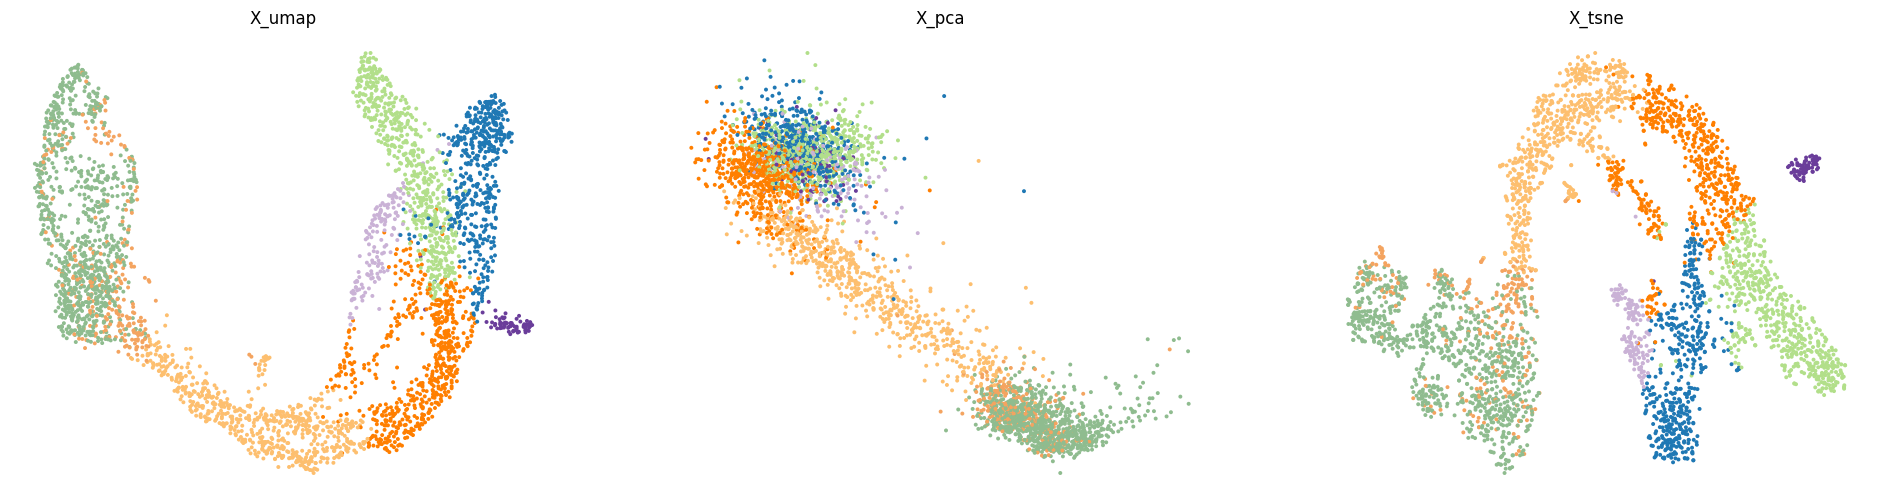

In [3]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt


fadata.obsm["X_tsne"] = np.loadtxt(f"tmp/26.01.20-metric_embedding/pancreas_tsne.csv")
basis_list = ["X_umap", "X_pca", "X_tsne"]
# fadata.obsm["X_random"] = np.random.randn(*fadata.obsm["X_umap"].shape) # random embedding
# basis_list = ["X_umap", "X_pca", "X_random"]

cluster_key = "clusters"

n = len(basis_list)
fig, ax = plt.subplots(1,n, figsize=(8*n, 6))
for i in range(n):
    basis = basis_list[i]
    # cafe.plot.plot_trajectory(fadata, basis=basis, ax=ax[i], show=False)
    sc.pl.embedding(fadata, basis=basis, color=cluster_key, title=basis, ax=ax[i], show=False, frameon=False, legend_loc=None)
plt.savefig(f"{img_dir}/pre_trajectory.pdf", dpi=300)

## 开发

计算单个指标

In [4]:
from cafe.metric.metric_embedding import \
    calculate_euclidean_distance_pc, \
    calculate_geodesic_distance_pc, \
    calculate_recluster_f1, \
    calculate_cluster_silhouette, \
    calculate_striped_score

basis = basis_list[0]
# pre trajectory dict
recluster_f1 = calculate_recluster_f1(fadata, basis=basis, cluster=cluster_key)
cluster_silhouette = calculate_cluster_silhouette(fadata, basis=basis, cluster=cluster_key)
striped_score = calculate_striped_score(fadata, basis=basis)
# after trajectory dict
euclidean_distance_pc = calculate_euclidean_distance_pc(fadata, model_name="ref", basis=basis)
geodesic_distance_pc = calculate_geodesic_distance_pc(fadata, model_name="ref", basis=basis)
recluster_f1, cluster_silhouette, striped_score, euclidean_distance_pc, geodesic_distance_pc

(0.5144362438216357,
 0.2282913,
 0.17158322056833558,
 0.9070064434943992,
 0.9838477978684314)

计算全部指标

In [5]:
from cafe.metric.metric_embedding import calculate_embedding_metric

embedding_metric = calculate_embedding_metric(fadata, basis)
embedding_metric

{'recluster_f1': 0.5144362438216357,
 'cluster_silhouette': 0.2282913,
 'striped_score': 0.17158322056833558,
 'euclidean_distance_pc': 0.9070064434943992,
 'geodesic_distance_pc': 0.9838477978684314}

## 应用

具体应用

1. 轨迹推断方法执行之前，用聚类指标评估聚类，用条带指标评估连贯性。

In [6]:
import pandas as pd
pd.options.display.precision = 3

from cafe.metric.metric_embedding import calculate_embedding_metric

metric_dict = {}
for basis in basis_list:
    embedding_metric = calculate_embedding_metric(fadata, basis=basis, pre_trajectory=True, post_trajectory=False)
    metric_dict[basis] = embedding_metric

print("Pre-trajectory")
metric_df = pd.DataFrame(metric_dict).T
metric_df

Pre-trajectory


,recluster_f1,cluster_silhouette,striped_score
X_umap,0.514,0.228,0.172
X_pca,0.498,0.152,0.062
X_tsne,0.495,0.266,0.154


2. 轨迹推断方法执行之后，用距离-伪时间相关性评估，其中几何距离（geodesic）比欧式距离（euclidean）更有效。

Choosing basis: X_umap
WARNING  |- unconnected milestones found: ['Delta']                                                                                                                                                     
WARNING  |- unconnected milestones found: ['Ngn3 low EP', 'Alpha', 'Epsilon', 'Ngn3 high EP', 'Pre-endocrine', 'Delta', 'Beta']                                                                         
Post-trajectory


,euclidean_distance_pc,geodesic_distance_pc
ref,0.907,0.984
pyrovelocity,0.745,0.811
veloae,0.007,0.009


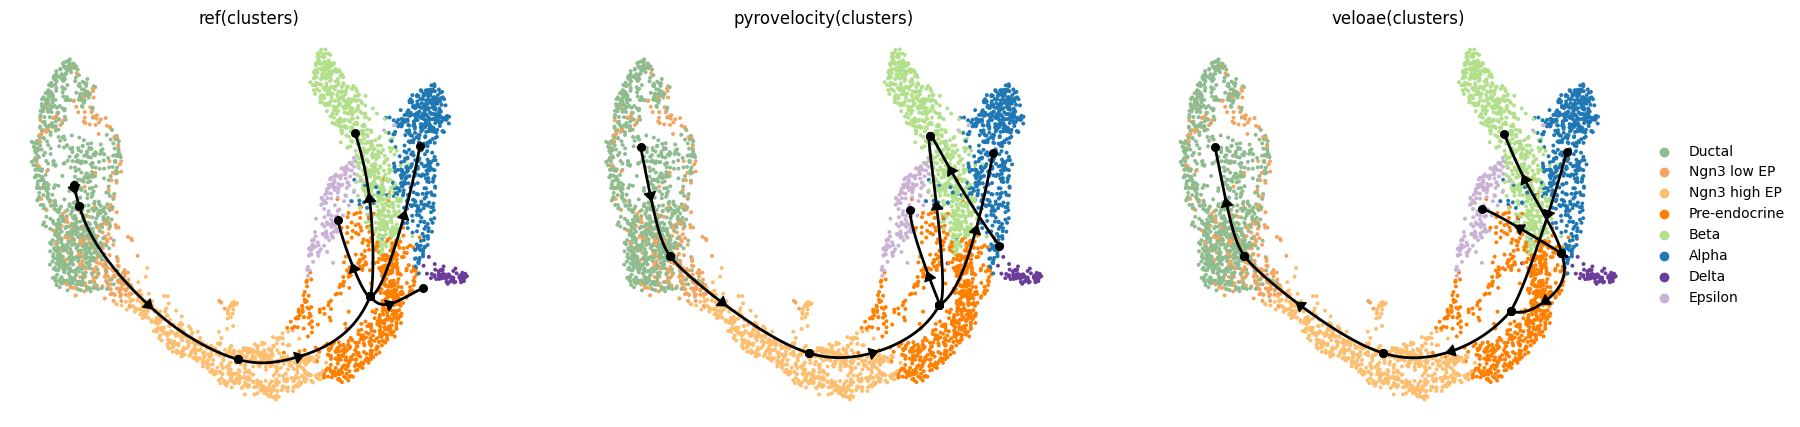

In [7]:
basis = basis_list[0] # best trajectory embedding
print("Choosing basis:", basis)

model_name_list = ["ref", "pyrovelocity", "veloae"]
fadata.load_trajectory_dict(model_name_list=model_name_list)

cafe.plot.plot_trajectory(fadata, basis=basis, model_name=model_name_list, save=f"{img_dir}/post_trajectory.pdf")

metric_dict = {}
for model_name in model_name_list:
    embedding_metric = calculate_embedding_metric(fadata, basis=basis, model_name=model_name, pre_trajectory=False, post_trajectory=True)
    metric_dict[model_name] = embedding_metric

print("Post-trajectory")
metric_df = pd.DataFrame(metric_dict).T
metric_df